# Librerias


In [35]:
# Cargamos todas las librerías necesarias
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import yfinance as yf
from scipy.stats import boxcox, norm, t as t_dist, jarque_bera
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.moment_helpers import cov2corr
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from pmdarima.utils import plot_acf, plot_pacf
from arch import arch_model
import itertools
 
from IPython.display import display

# Carga de datos y creación de variables de interes

In [ ]:
# intervalo: diario
df = yf.download("SPY", start="2010-01-01", end="2024-12-31",
                 interval="1d", auto_adjust=False)
 
# Mantenemos solo columnas que nos son relevantes
df = df[["Close"]]
 
# Construimos algunas variables de interes.
df["Change"]     = df["Close"].pct_change()
df["Change %"]   = df["Change"] * 100
 
df = df.dropna()
print(df.describe())
print(df.shape)

[*********************100%***********************]  1 of 1 completed

Price         Close       Change     Change %
Ticker          SPY                          
count   3772.000000  3772.000000  3772.000000
mean     272.455064     0.000495     0.049501
std      125.893958     0.010781     1.078071
min      102.199997    -0.109424   -10.942374
25%      170.297497    -0.003809    -0.380910
50%      243.049995     0.000635     0.063514
75%      380.404991     0.005775     0.577527
max      607.809998     0.090603     9.060326
(3772, 3)


# Visualización

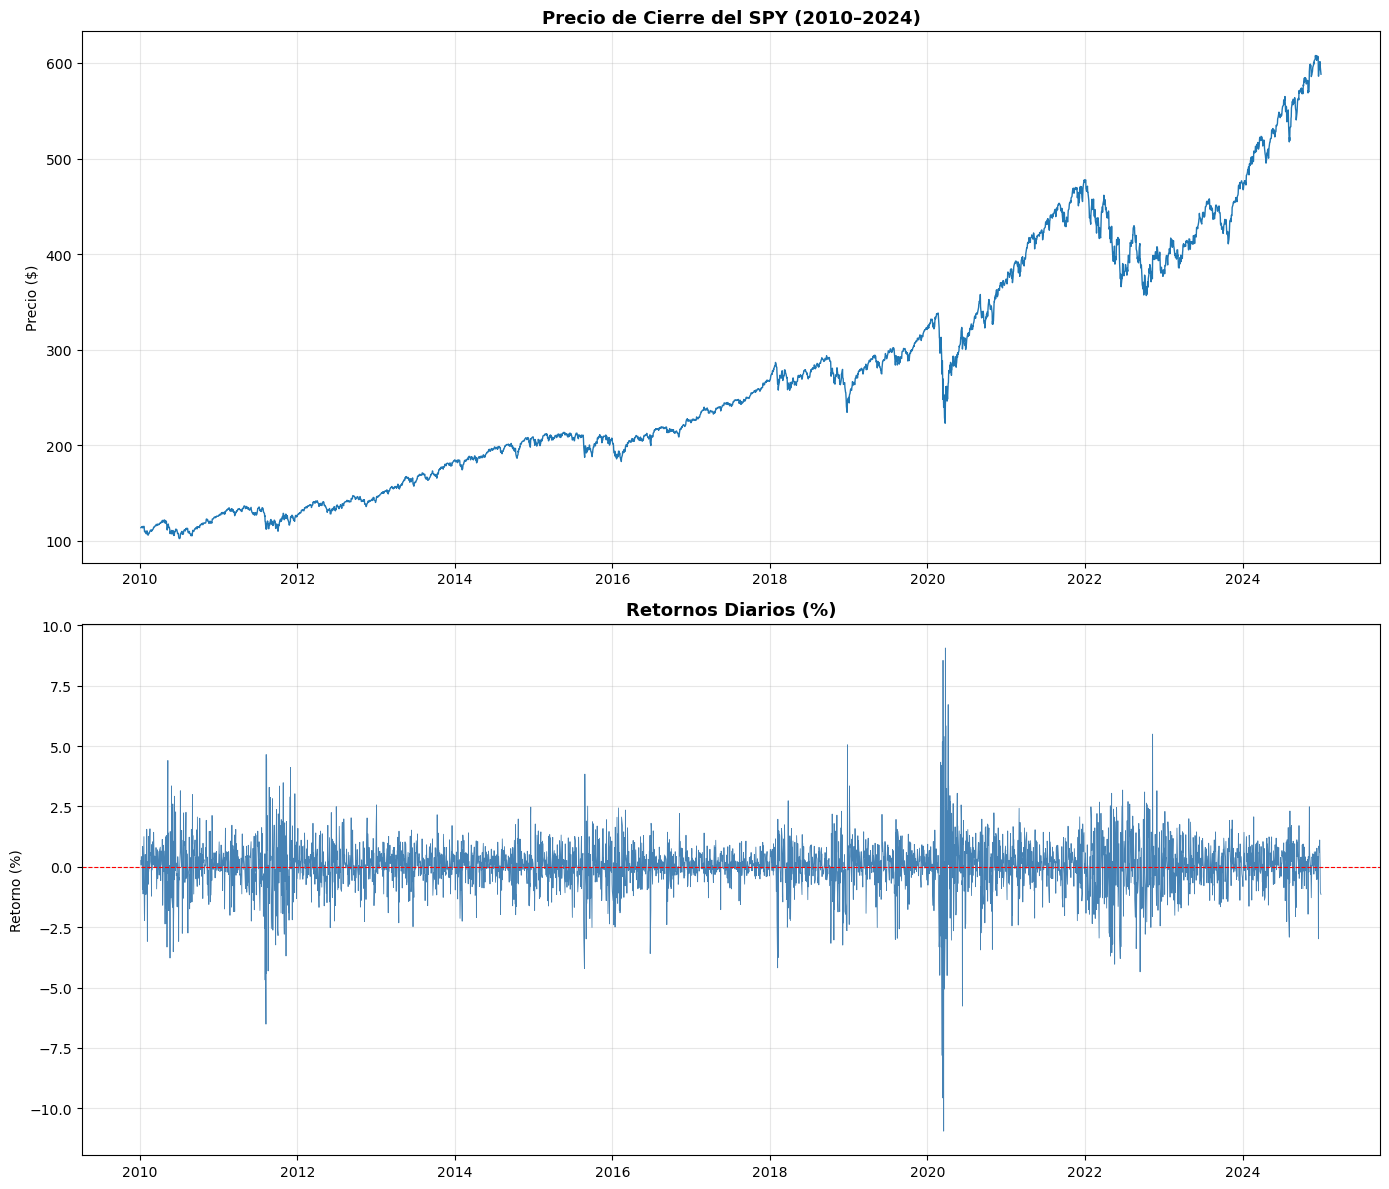

In [37]:
# Representamos la evolución del precio de cierre, los retornos diarios
 
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)
 
axes[0].plot(df.index, df["Close"], linewidth=1)
axes[0].set_title("Precio de Cierre del SPY (2010–2024)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Precio ($)")
axes[0].grid(True, alpha=0.3)
 
axes[1].plot(df.index, df["Change %"], linewidth=0.6, color="steelblue")
axes[1].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title("Retornos Diarios (%)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Retorno (%)")
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.show()

# Split train/test

In [38]:

# Este split se aplica tanto a la serie de precios (para ARIMA) como a la serie de retornos (para GARCH).
 
fecha_corte = df.index.max() - pd.DateOffset(years=1)
 
# — Serie de precios (para ARIMA)
df_arima      = df["Close"]
df_a_train    = df_arima[df_arima.index < fecha_corte]
df_a_test     = df_arima[df_arima.index >= fecha_corte]
 
# — Serie de retornos (para GARCH)
residuos      = df["Change %"]
res_train     = residuos[residuos.index < fecha_corte]
res_test      = residuos[residuos.index >= fecha_corte]
 
print(f"Train precios : {df_a_train.shape[0]} obs.  ({df_a_train.index[0].date()} → {df_a_train.index[-1].date()})")
print(f"Test  precios : {df_a_test.shape[0]}  obs.  ({df_a_test.index[0].date()} → {df_a_test.index[-1].date()})")
print(f"Train retornos: {res_train.shape[0]} obs.")
print(f"Test  retornos: {res_test.shape[0]}  obs.")
 

Train precios : 3521 obs.  (2010-01-05 → 2023-12-29)
Test  precios : 251  obs.  (2024-01-02 → 2024-12-30)
Train retornos: 3521 obs.
Test  retornos: 251  obs.


# ARIMA

## Pre-calculos


In [ ]:
# Box-Cox -- (Estacionariedad en varianza)
_, lam = boxcox(np.asarray(df_a_train).ravel())
print(f"\nTest Box-Cox → λ estimado = {lam:.4f}")
 


Test Box-Cox → λ estimado = 0.0631


In [40]:
# Como el parametro se aproxima a 0, es adecuado una transformación logaritmica.
# Transformamos la serie
df_a_logtrain = np.log(df_a_train)
df_a_logtest  = np.log(df_a_test)

In [41]:
# Dickey-Fuller sobre la serie log -- (Estacionariedad en media)
result = adfuller(df_a_logtrain)
print(f"\nTest ADF sobre log(Precio) — serie de entrenamiento")
print(f"  ADF statistic : {result[0]:.4f}")
print(f"  p-valor       : {result[1]:.4f}")
print("  Valores críticos:")
for key, val in result[4].items():
    print(f"    {key}: {val:.3f}")

# Como p > 0.05 nos dice que hay una raiz unitaria y deberiamos diferenciar.
# Sin embargo, nos apoyaremos en mas que este test para ello.


Test ADF sobre log(Precio) — serie de entrenamiento
  ADF statistic : -0.7548
  p-valor       : 0.8320
  Valores críticos:
    1%: -3.432
    5%: -2.862
    10%: -2.567


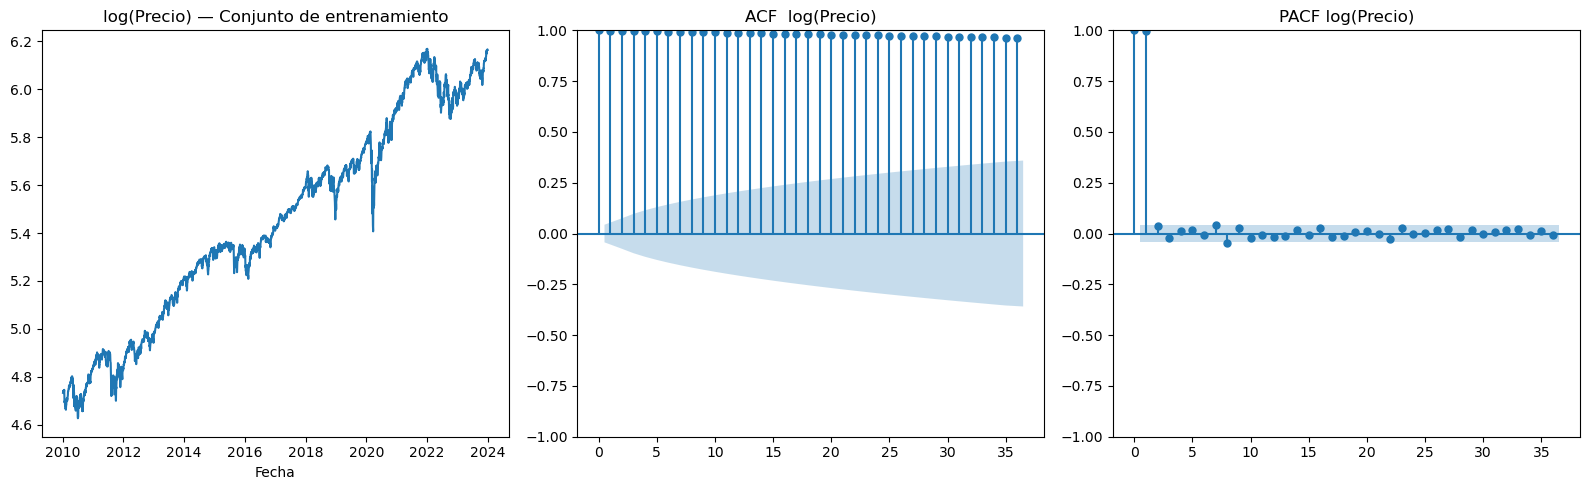

In [42]:
# Veamos un resumen de los datos con los que trabajaremos.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].plot(df_a_logtrain)
axes[0].set_title("log(Precio) — Conjunto de entrenamiento")
axes[0].set_xlabel("Fecha")
plot_acf(df_a_logtrain,  ax=axes[1], title="ACF  log(Precio)", show=False, alpha=0.01)
plot_pacf(df_a_logtrain, ax=axes[2], title="PACF log(Precio)", show=False, alpha=0.01)
plt.tight_layout()
plt.show()

## Estimacion y diagnostico

In [43]:
# Definimos las funciones auxiliares para poder ajustar nuestros modelos.

def calcular_metricas(y_real_log, y_pred_log, label=""):
    """Calcula MAE, RMSE y MAPE en escala original (exponencial de los logs)."""
    y_real = np.exp(np.asarray(y_real_log, dtype=float))
    y_pred = np.exp(np.asarray(y_pred_log, dtype=float))
    errores = y_real - y_pred
    mae  = float(np.abs(errores).mean())
    rmse = float(np.sqrt((errores**2).mean()))
    mape = float((np.abs(errores) / np.abs(y_real)).mean() * 100)
    print(f"\n{'─'*40}")
    print(f"  Métricas de error {label}")
    print(f"{'─'*40}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.4f} %")
    print(f"{'─'*40}\n")
    return mae, rmse, mape
 
def resumen_arima(modelo, target_log):
    """Muestra métricas, summary, correlaciones y ACF/PACF de residuos."""
    calcular_metricas(target_log, modelo.fittedvalues, label="(train, escala original)")
    display(modelo.summary())
    covs = modelo.cov_params()
    display(pd.DataFrame(cov2corr(covs), columns=covs.columns, index=covs.index))
    fig, axarray = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf( modelo.resid, ax=axarray[0], lags=20, show=False, alpha=0.05)
    plot_pacf(modelo.resid, ax=axarray[1], lags=20, method="ols", show=False, alpha=0.05)
    plt.tight_layout()
    plt.show()
    print("\nTest de Ljung-Box sobre residuos (lags 1-10):")
    print(acorr_ljungbox(modelo.resid, lags=10))
 


────────────────────────────────────────
  Métricas de error (train, escala original)
────────────────────────────────────────
  MAE  : 120.6579
  RMSE : 150.7548
  MAPE : 55.4690 %
────────────────────────────────────────



<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    SPY   No. Observations:                 3521
Model:               SARIMAX(1, 0, 0)   Log Likelihood               10878.151
Date:                Mon, 27 Apr 2026   AIC                         -21752.302
Time:                        22:08:39   BIC                         -21739.969
Sample:                             0   HQIC                        -21747.902
                               - 3521                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   1.43e-05      7e+04      0.000       1.000       1.000
sigma2         0.0001   1.12e-06    107.540      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                  37.39   Jarque-Bera (JB):             19124.04
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.81   Skew:                            -0.71
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

,ar.L1,sigma2
ar.L1,1.000000,0.074352
sigma2,0.074352,1.000000


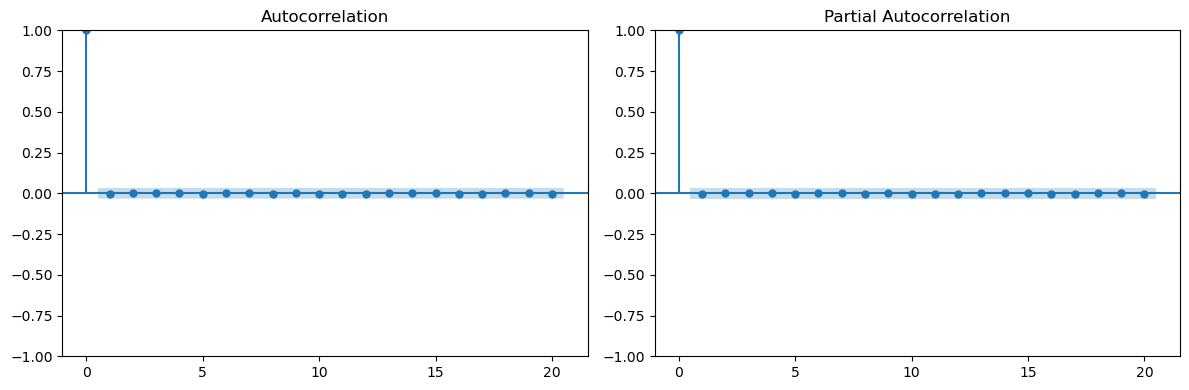


Test de Ljung-Box sobre residuos (lags 1-10):
     lb_stat  lb_pvalue
1   0.012170   0.912159
2   0.025606   0.987279
3   0.025615   0.998918
4   0.026379   0.999914
5   0.040697   0.999982
6   0.040915   0.999999
7   0.061895   1.000000
8   0.121480   0.999999
9   0.182718   1.000000
10  0.206965   1.000000


In [44]:
# Gracias a las funciones de autocorrelacion, proponemos un ARIMA(1,0,0)
modelo1 = SARIMAX(df_a_logtrain, order=(1, 0, 0)).fit()
resumen_arima(modelo1, df_a_logtrain)


── ARIMA(0,1,0) — Modelo definitivo ──

────────────────────────────────────────
  Métricas de error (train, escala original)
────────────────────────────────────────
  MAE  : 120.6587
  RMSE : 150.7558
  MAPE : 55.4697 %
────────────────────────────────────────



<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    SPY   No. Observations:                 3521
Model:               SARIMAX(0, 1, 0)   Log Likelihood               10881.273
Date:                Mon, 27 Apr 2026   AIC                         -21760.545
Time:                        22:08:40   BIC                         -21754.379
Sample:                             0   HQIC                        -21758.345
                               - 3521                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0001   1.12e-06    107.781      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                  37.40   Jarque-Bera (JB):             19120.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.81   Skew:                            -0.71
Prob(H) (two-sided):                  0.00   Kurtosis:                        14.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

,sigma2
sigma2,1.0


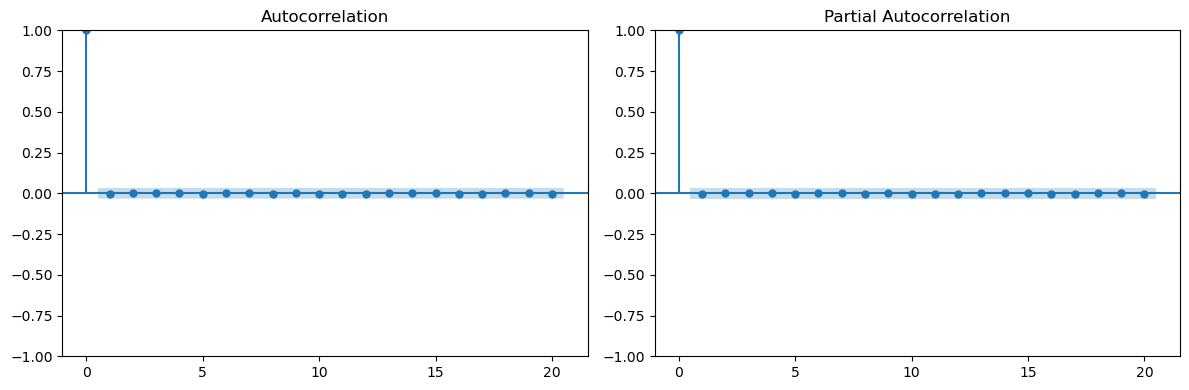


Test de Ljung-Box sobre residuos (lags 1-10):
     lb_stat  lb_pvalue
1   0.012166   0.912173
2   0.025606   0.987279
3   0.025615   0.998918
4   0.026378   0.999914
5   0.040692   0.999982
6   0.040910   0.999999
7   0.061896   1.000000
8   0.121472   0.999999
9   0.182718   1.000000
10  0.206960   1.000000


In [45]:
# Vemos que el parámetro del AR se ha ido a 1, luego diferenciamos
# Que venia a ser lo que nos pedía anteriormente el test de Dickye-Fuller.
print("\n── ARIMA(0,1,0) — Modelo definitivo ──")
modelo2 = SARIMAX(df_a_logtrain, order=(0, 1, 0)).fit()
resumen_arima(modelo2, df_a_logtrain)

In [46]:
# Como ya hemos obtenido ruido blanco, este es el mejor modelo para predecir en media.
# Hemos ajustado log(Y_t)=log(Y_t-1)+a_t

## Calculo de predicciones y errores


────────────────────────────────────────
  Métricas de error ARIMA(0,1,0) — horizonte h=5 días
────────────────────────────────────────
  MAE  : 5.0620
  RMSE : 5.8169
  MAPE : 1.0802 %
────────────────────────────────────────



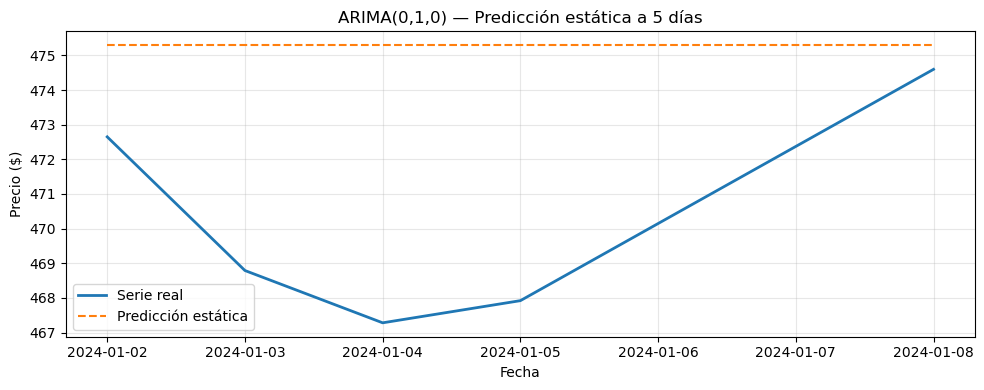


────────────────────────────────────────
  Métricas de error ARIMA(0,1,0) — horizonte h=20 días
────────────────────────────────────────
  MAE  : 6.3115
  RMSE : 8.0679
  MAPE : 1.3078 %
────────────────────────────────────────



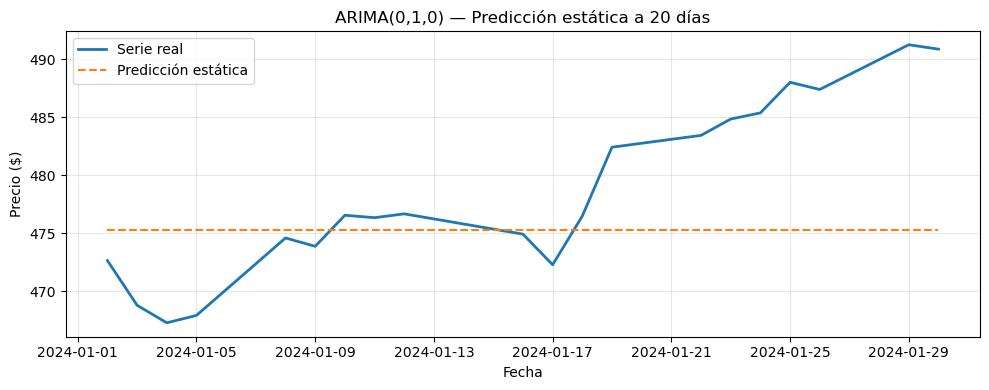


────────────────────────────────────────
  Métricas de error ARIMA(0,1,0) — horizonte h=40 días
────────────────────────────────────────
  MAE  : 14.8565
  RMSE : 18.0721
  MAPE : 2.9923 %
────────────────────────────────────────



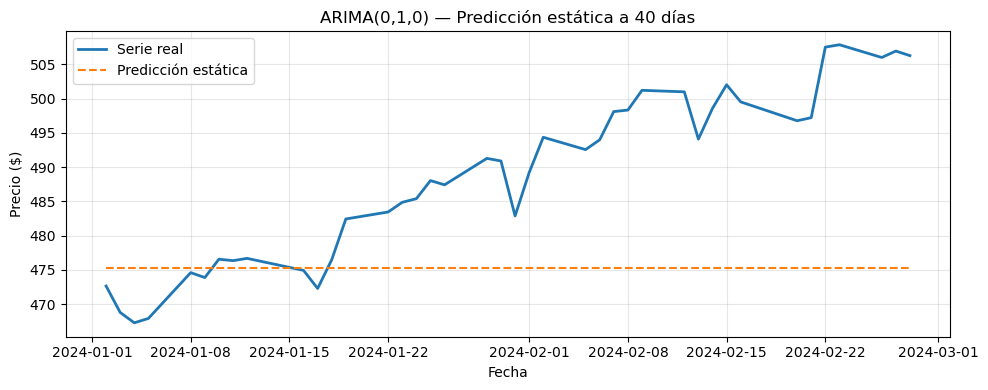


────────────────────────────────────────
  Métricas de error ARIMA(0,1,0) — horizonte h=251 días
────────────────────────────────────────
  MAE  : 66.1661
  RMSE : 75.4446
  MAPE : 11.8254 %
────────────────────────────────────────



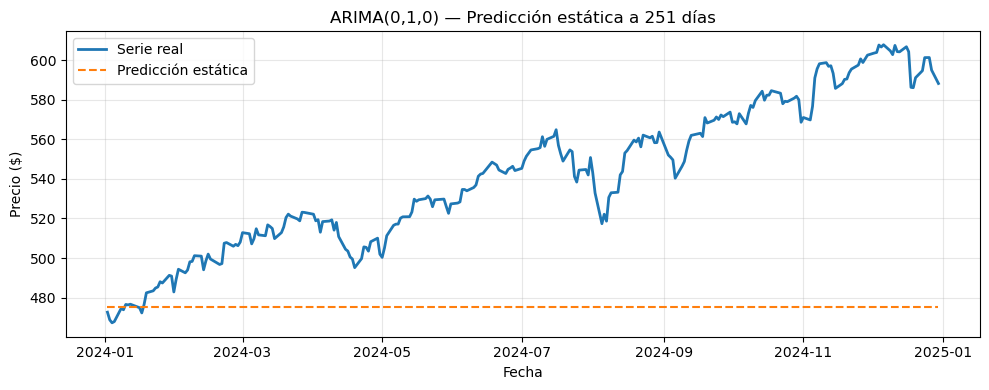

In [ ]:
# Veamos como se va aumentando el error al ampliar la ventana de predicción
ventanas = [5, 20, 40, 251]
resultados_estaticos = {}
 
for dias in ventanas:
    pred = modelo2.forecast(steps=dias)
    pred.index = df_a_logtest[:dias].index
    pred = pred.to_frame(name="predic")
    mae, rmse, mape = calcular_metricas(
        df_a_logtest[:dias], pred["predic"],
        label=f"ARIMA(0,1,0) — horizonte h={dias} días"
    )
    resultados_estaticos[dias] = {"MAE": mae, "RMSE": rmse, "MAPE": mape}
 
    plt.figure(figsize=(10, 4))
    plt.plot(df_a_logtest[:dias].index, np.exp(df_a_logtest[:dias]),
             label="Serie real", linewidth=2)
    plt.plot(pred.index, np.exp(pred["predic"]),
             label="Predicción estática", linestyle="--")
    plt.title(f"ARIMA(0,1,0) — Predicción estática a {dias} días")
    plt.xlabel("Fecha"); plt.ylabel("Precio ($)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.show()

In [48]:
# Los errores van aumentando, al perderse la localidad de las predicciones.
# Con este modelo, solo interesa predecir a horizonte 1


Ejecutando rolling forecast ARIMA (251 pasos)…
  Paso 50/251 completado
  Paso 100/251 completado
  Paso 150/251 completado
  Paso 200/251 completado
  Paso 250/251 completado

────────────────────────────────────────
  Métricas de error Rolling forecast ARIMA(0,1,0)
────────────────────────────────────────
  MAE  : 3.1912
  RMSE : 4.3229
  MAPE : 0.5912 %
────────────────────────────────────────



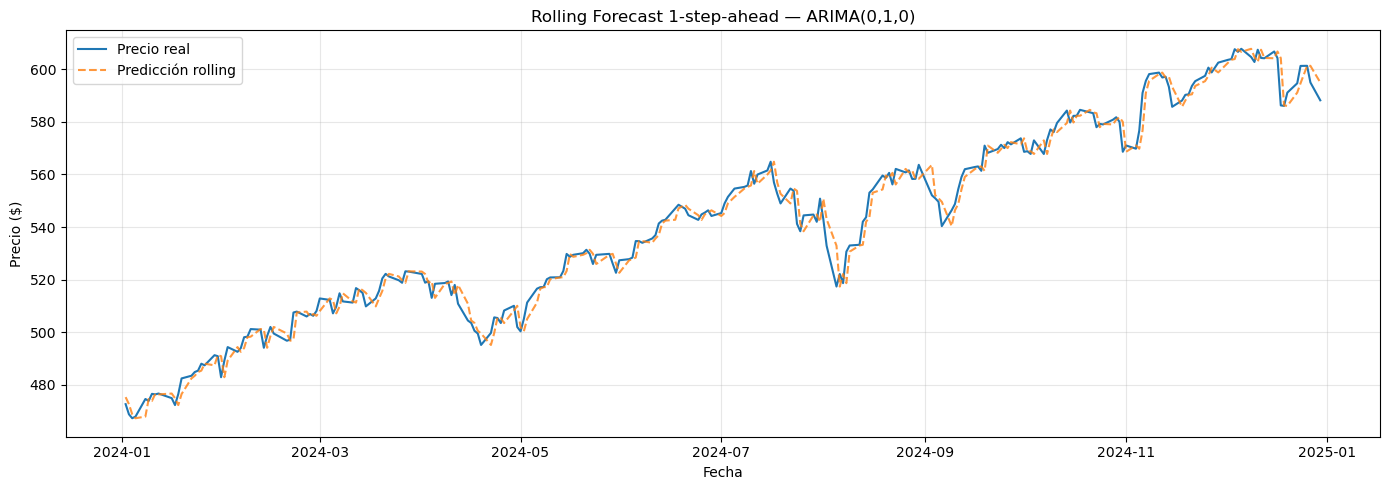

In [ ]:
# Para ello, introducimos el rolling forecast
# ROLLING FORECAST — ARIMA(0,1,0)

 
def rolling_forecast_arima(serie_log, train_size, order=(0, 1, 0)):
    historia = list(serie_log[:train_size])
    predicciones_log, fechas = [], []
    n_test = len(serie_log) - train_size
 
    for i in range(n_test):
        modelo = SARIMAX(historia, order=order).fit(disp=False, warn_convergence=False)
        pred   = modelo.forecast(steps=1)
        predicciones_log.append(float(np.asarray(pred).ravel()[0]))
        fechas.append(serie_log.index[train_size + i])
        historia.append(serie_log.iloc[train_size + i])
        if (i + 1) % 50 == 0:
            print(f"  Paso {i+1}/{n_test} completado")
 
    return pd.DataFrame({
        "real": np.exp(np.asarray(serie_log[train_size:], dtype=float)),
        "pred": np.exp(np.asarray(predicciones_log, dtype=float)),
        "pred_log": np.asarray(predicciones_log, dtype=float)
    }, index=fechas)
 
 
serie_completa_log = pd.concat([df_a_logtrain, df_a_logtest]).squeeze()
train_size         = len(df_a_logtrain)
 
print(f"\nEjecutando rolling forecast ARIMA ({len(df_a_logtest)} pasos)…")
resultados_rolling = rolling_forecast_arima(serie_completa_log, train_size)
 
calcular_metricas(
    np.log(resultados_rolling["real"]),
    np.log(resultados_rolling["pred"]),
    label="Rolling forecast ARIMA(0,1,0)"
)
 
plt.figure(figsize=(14, 5))
plt.plot(resultados_rolling.index, resultados_rolling["real"],
         label="Precio real", linewidth=1.5)
plt.plot(resultados_rolling.index, resultados_rolling["pred"],
         label="Predicción rolling", linewidth=1.5, linestyle="--", alpha=0.8)
plt.title("Rolling Forecast 1-step-ahead — ARIMA(0,1,0)")
plt.xlabel("Fecha"); plt.ylabel("Precio ($)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

# GARCH

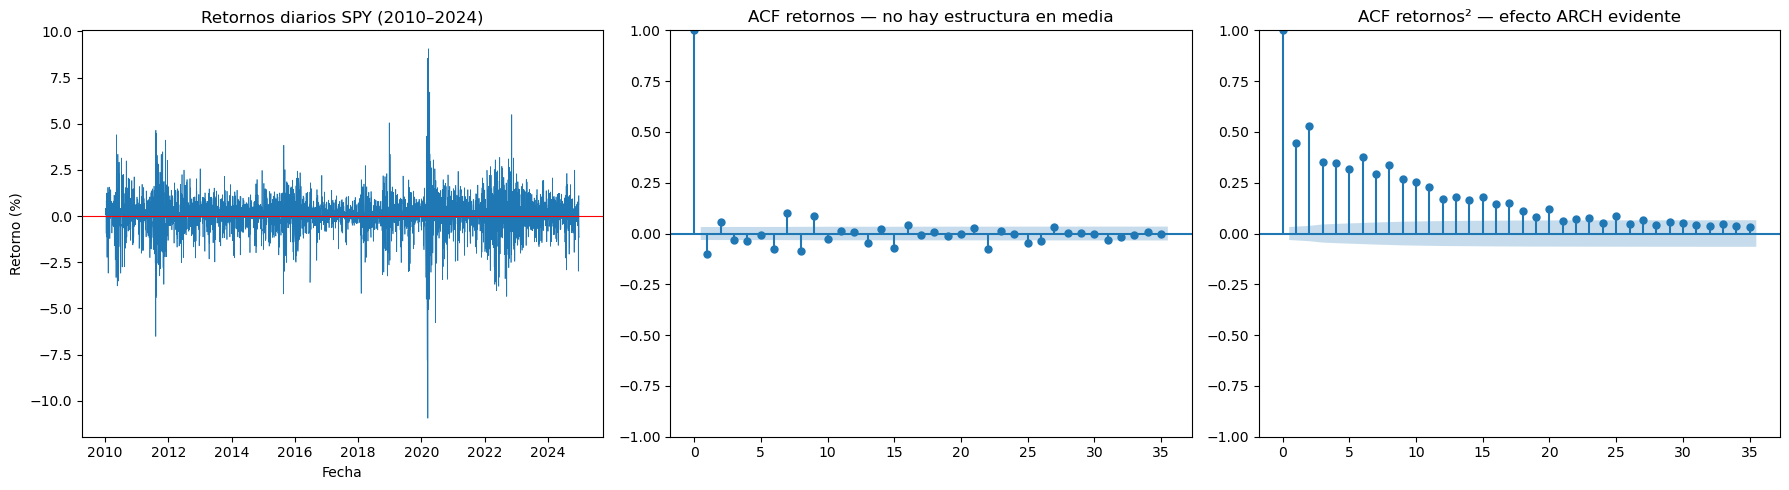

In [50]:
# Como los residuos de nuestro ARIMA son equivalentes a los retornos, podremos trabajar ya directamente con ellos.
# Hay dos hechos que motivan la utlización de modelos GARCH
# Veamos como existe correlación entre los retornos de forma gráfica
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
axes[0].plot(residuos.index, residuos, linewidth=0.5)
axes[0].axhline(0, color="red", linewidth=0.8)
axes[0].set_title("Retornos diarios SPY (2010–2024)")
axes[0].set_xlabel("Fecha"); axes[0].set_ylabel("Retorno (%)")
 
sm_plot_acf(residuos, ax=axes[1], lags=35, alpha=0.05)
axes[1].set_title("ACF retornos — no hay estructura en media")
 
sm_plot_acf(residuos**2, ax=axes[2], lags=35, alpha=0.05)
axes[2].set_title("ACF retornos² — efecto ARCH evidente")
 
plt.tight_layout()
plt.show()

In [51]:
# Y vemos que el contraste LM de Engle nos dice que hay efecto ARCH
 
print("\n" + "─"*55)
print("  Test ARCH de Engle — serie completa (2010–2024)")
print("─"*55)
for nlags in [5, 10, 20]:
    stat, pval, _, _ = het_arch(residuos, nlags=nlags)
    sig = "✓ Efectos ARCH presentes" if pval < 0.05 else "✗ No significativo"
    print(f"  nlags={nlags:2d} → estadístico: {stat:.4f}, p-valor: {pval:.6f}  {sig}")


───────────────────────────────────────────────────────
  Test ARCH de Engle — serie completa (2010–2024)
───────────────────────────────────────────────────────
  nlags= 5 → estadístico: 1291.0465, p-valor: 0.000000  ✓ Efectos ARCH presentes
  nlags=10 → estadístico: 1375.1141, p-valor: 0.000000  ✓ Efectos ARCH presentes
  nlags=20 → estadístico: 1408.7018, p-valor: 0.000000  ✓ Efectos ARCH presentes


## Justificación t-Student

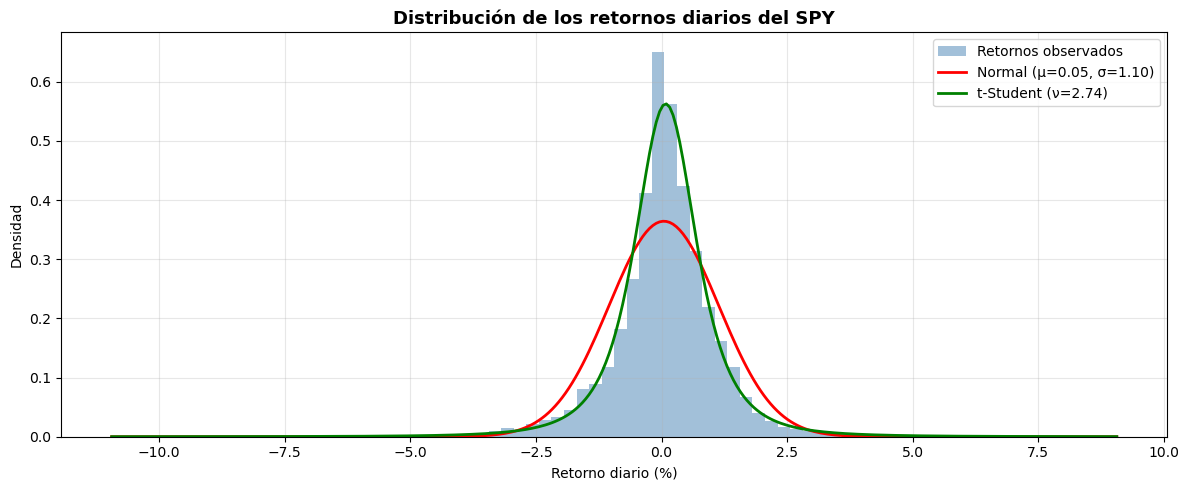


Curtosis : 10.6122  (> 3 → leptocúrtica)
Asimetría: -0.5029
------------------------------------------------------------
Jarque-Bera: estadístico=16618.20, p-valor=0.000000
→ Se rechaza la normalidad (p < 0.05): usaremos distribución t-Student en el GARCH.


In [ ]:

# Comprobemos que la distribución de los retornos se ajusta más a una t-Student que a una normal como nos dice la teoría.
# Lo vemos de forma gráfica, mediante el test de Jarque-Bera que rechaza normalidad de residuos y mediante la curtosis 
# que al ser 10 nos indica colas muy pesadas y la Asimetria.
 
mu_norm, std_norm        = norm.fit(res_train)
nu_t, mu_t, std_t        = t_dist.fit(res_train)
x                        = np.linspace(res_train.min(), res_train.max(), 300)
 
plt.figure(figsize=(12, 5))
plt.hist(res_train, bins=80, density=True, color="steelblue", alpha=0.5,
         label="Retornos observados")
plt.plot(x, norm.pdf(x, mu_norm, std_norm), color="red",   linewidth=2,
         label=f"Normal (μ={mu_norm:.2f}, σ={std_norm:.2f})")
plt.plot(x, t_dist.pdf(x, nu_t, mu_t, std_t), color="green", linewidth=2,
         label=f"t-Student (ν={nu_t:.2f})")
plt.xlabel("Retorno diario (%)"); plt.ylabel("Densidad")
plt.title("Distribución de los retornos diarios del SPY", fontsize=13, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()
 
print(f"\nCurtosis : {res_train.kurt():.4f}  (> 3 → leptocúrtica)")
print(f"Asimetría: {res_train.skew():.4f}")
print('-'*60)
stat_jb, pval_jb = jarque_bera(res_train)
print(f"Jarque-Bera: estadístico={stat_jb:.2f}, p-valor={pval_jb:.6f}")
print("→ Se rechaza la normalidad (p < 0.05): usaremos distribución t-Student en el GARCH.")
 

## Selección de orden del modelo

In [53]:
# Usaremos AIC y BIC
best_bic, best_order, results_grid = np.inf, None, []
 
for p, q in itertools.product(range(0, 4), range(0, 4)):
    try:
        m   = arch_model(res_train, vol="Garch", p=p, q=q, dist="t")
        res = m.fit(disp="off")
        results_grid.append((p, q, res.aic, res.bic))
        if res.bic < best_bic:
            best_bic   = res.bic
            best_order = (p, q)
    except Exception:
        continue
 
df_grid = pd.DataFrame(results_grid, columns=["p", "q", "AIC", "BIC"])
print("\nSelección de orden GARCH — tabla AIC/BIC:")
print(df_grid.sort_values("BIC").to_string(index=False))
print(f"\nMejor modelo por BIC: GARCH{best_order}")

# Decidimos adoptar el modelo GARCH(1,1) ya que el BIC lo reespalda y la AIC no se diferencia tanto del reto.
# Ademas, este es el modelo respaldado por la literatura.


Selección de orden GARCH — tabla AIC/BIC:
 p  q         AIC         BIC
 1  1 8907.899342 8938.731844
 2  1 8902.543221 8939.542223
 2  2 8903.567501 8946.733003
 1  2 8909.899342 8946.898344
 3  1 8904.543222 8947.708724
 2  3 8904.690223 8954.022225
 3  2 8905.445369 8954.777372
 1  3 8911.899343 8955.064845
 3  3 8906.596620 8962.095123
 3  0 9069.488113 9106.487115
 2  0 9211.254094 9242.086595
 1  0 9484.106885 9508.772887

Mejor modelo por BIC: GARCH(1, 1)


In [54]:
# Vemos un resumen del modelo para ver cuáles son los parámetros.
modelo_garch = arch_model(res_train, vol="Garch", p=1, q=1, dist="t")
res_final    = modelo_garch.fit(disp="off")
print(res_final.summary())
 
alpha1 = res_final.params["alpha[1]"]
beta1  = res_final.params["beta[1]"]
omega  = res_final.params["omega"]
nu     = res_final.params["nu"]

print('-'*60)
print(f"\nPersistencia α̂₁ + β̂₁ = {alpha1 + beta1:.4f}  {'(≈ 1 → comportamiento IGARCH)' if alpha1 + beta1 > 0.95 else ''}")
print('-'*60)
print(f"Varianza incondicional estimada: {omega / (1 - alpha1 - beta1):.4f} %²  (si estacionaria)")
print(f"Grados de libertad ν (t-Student): {nu:.2f}")
 

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                     Change %   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -4448.95
Distribution:      Standardized Student's t   AIC:                           8907.90
Method:                  Maximum Likelihood   BIC:                           8938.73
                                              No. Observations:                 3521
Date:                      Mon, Apr 27 2026   Df Residuals:                     3520
Time:                              22:09:16   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

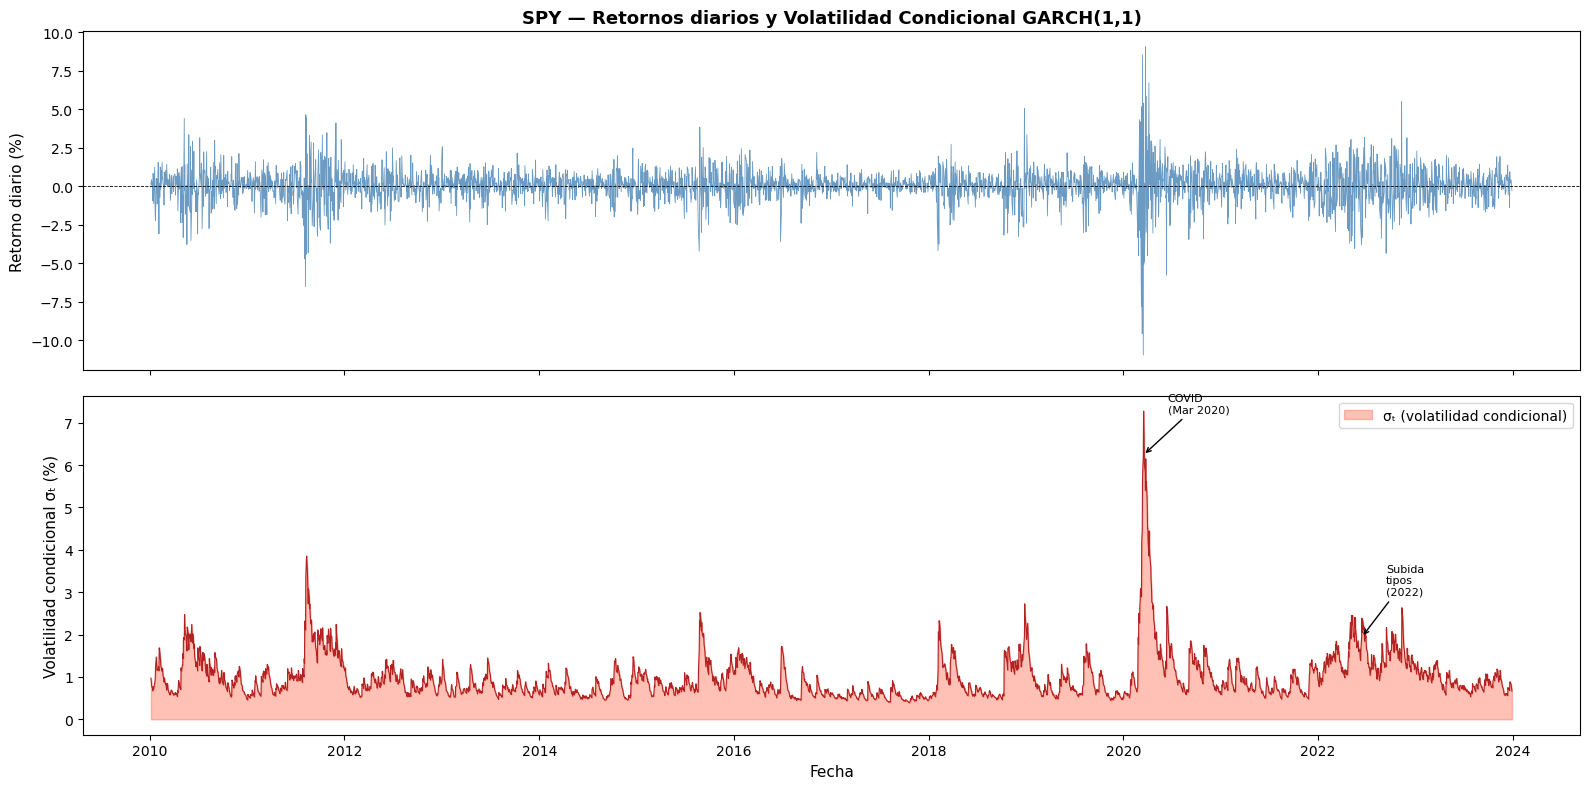

In [55]:
# Veamos como se ajustaria el modelo sobre el train de nuestros datos para ver como recoge
# momentos de alta y baja volatilidad.
 
vol_cond = res_final.conditional_volatility
 
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
 
axes[0].plot(res_train.index, res_train.values, linewidth=0.6, color="steelblue", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.6, linestyle="--")
axes[0].set_ylabel("Retorno diario (%)", fontsize=11)
axes[0].set_title("SPY — Retornos diarios y Volatilidad Condicional GARCH(1,1)",
                  fontsize=13, fontweight="bold")
 
axes[1].fill_between(res_train.index, vol_cond, alpha=0.4, color="tomato",
                     label="σₜ (volatilidad condicional)")
axes[1].plot(res_train.index, vol_cond, color="firebrick", linewidth=0.8)
axes[1].set_ylabel("Volatilidad condicional σₜ (%)", fontsize=11)
axes[1].set_xlabel("Fecha", fontsize=11)
axes[1].legend(fontsize=10)
 
eventos = {
    "COVID\n(Mar 2020)": "2020-03-16",
    "Subida\ntipos\n(2022)":  "2022-06-13",
}
for label, fecha in eventos.items():
    idx = pd.Timestamp(fecha)
    if idx in vol_cond.index:
        y_val = vol_cond[idx]
        axes[1].annotate(label, xy=(idx, y_val),
                         xytext=(idx + pd.DateOffset(months=3), y_val + 1),
                         arrowprops=dict(arrowstyle="->", color="black"),
                         fontsize=8)
 
plt.tight_layout()
plt.show()
 

## Diagnostico


Test ARCH sobre residuos estandarizados (nlags=10):
  p-valor = 0.6812  → No queda efecto ARCH ✓

Test de Ljung-Box sobre ẑₜ² (lags 1-10):
     lb_stat  lb_pvalue
1   0.217465   0.640978
2   2.537050   0.281246
3   2.794300   0.424439
4   3.308991   0.507509
5   3.940031   0.558082
6   4.153575   0.655902
7   5.317668   0.621258
8   6.049320   0.641707
9   6.618186   0.676803
10  7.725297   0.655649


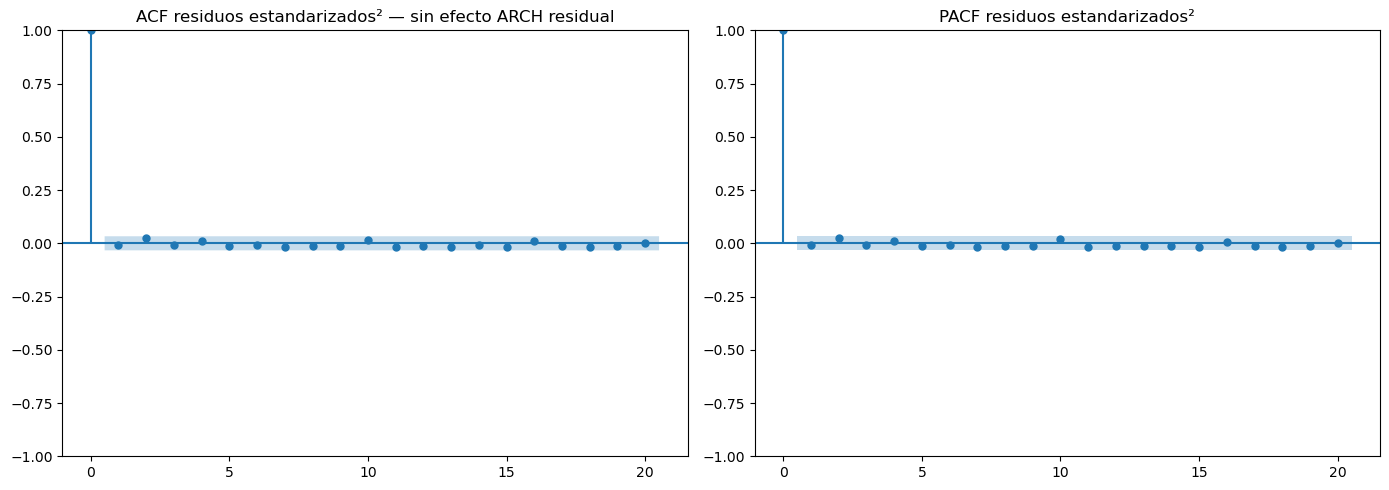

In [56]:
# Por último hagamos un diagnistico de nuestros resultados y veamos si recoge toda la estructura ARCH
resid_std = res_final.resid / res_final.conditional_volatility
 
# Test ARCH sobre residuos estandarizados
stat_arch, pval_arch, _, _ = het_arch(resid_std, nlags=10)
print(f"\nTest ARCH sobre residuos estandarizados (nlags=10):")
print(f"  p-valor = {pval_arch:.4f}  {'→ No queda efecto ARCH ✓' if pval_arch > 0.05 else '→ Aún hay efecto ARCH ✗'}")
 
# Test de Ljung-Box sobre ẑₜ²
lb_result = acorr_ljungbox(resid_std**2, lags=10)
print("\nTest de Ljung-Box sobre ẑₜ² (lags 1-10):")
print(lb_result)
 
# ACF de ẑₜ²
fig, axarray = plt.subplots(1, 2, figsize=(14, 5))
sm_plot_acf(resid_std**2, ax=axarray[0], lags=20, alpha=0.05)
axarray[0].set_title("ACF residuos estandarizados² — sin efecto ARCH residual")
plot_pacf(resid_std**2, ax=axarray[1], lags=20, method="ols", show=False, alpha=0.05)
axarray[1].set_title("PACF residuos estandarizados²")
plt.tight_layout()
plt.show()

## Rolling forecast GARCH


Ejecutando rolling forecast GARCH (251 pasos)…
  Paso 50/251 completado
  Paso 100/251 completado
  Paso 150/251 completado
  Paso 200/251 completado
  Paso 250/251 completado

────────────────────────────────────────
  Métricas de evaluación GARCH(1,1)
────────────────────────────────────────
  MSE  varianza : 1.408759
  QLIKE         : 0.558910
────────────────────────────────────────


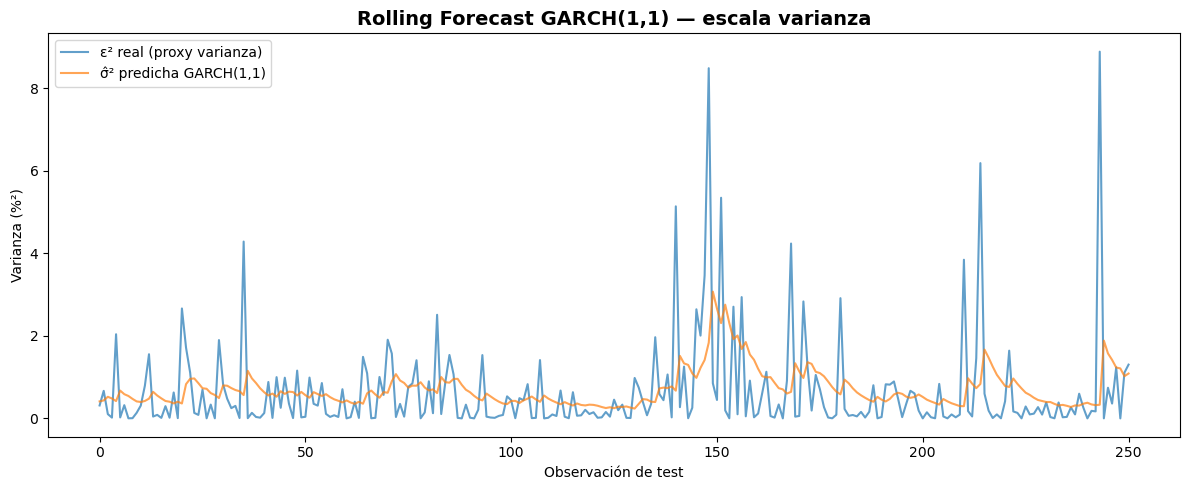

In [57]:

# Hacemos tambien el rolling forecast para hacer predicciones y comprobar el ajuste mediante las metricas de error.
# En este caso usando la QLIKE como medida por exelencia.
 
rolling_var_pred = []
historia_ret     = list(res_train)
 
print(f"\nEjecutando rolling forecast GARCH ({len(res_test)} pasos)…")
for i, ret_real in enumerate(res_test):
    m    = arch_model(historia_ret, vol="Garch", p=1, q=1, dist="t")
    r    = m.fit(disp="off")
    pred = r.forecast(horizon=1)
    rolling_var_pred.append(pred.variance.values[-1, 0])
    historia_ret.append(ret_real)
    if (i + 1) % 50 == 0:
        print(f"  Paso {i+1}/{len(res_test)} completado")
 
rolling_var_pred = np.array(rolling_var_pred)
sigma2_real      = res_test.values**2
 
mse_garch   = np.mean((sigma2_real - rolling_var_pred)**2)
qlike_garch = np.mean(np.log(rolling_var_pred) + sigma2_real / rolling_var_pred)
 
print(f"\n{'─'*40}")
print("  Métricas de evaluación GARCH(1,1)")
print(f"{'─'*40}")
print(f"  MSE  varianza : {mse_garch:.6f}")
print(f"  QLIKE         : {qlike_garch:.6f}")
print(f"{'─'*40}")
 
# Gráfico σ̂² predicha vs ε² real
plt.figure(figsize=(12, 5))
plt.plot(sigma2_real,        label="ε² real (proxy varianza)",    alpha=0.7)
plt.plot(rolling_var_pred,   label="σ̂² predicha GARCH(1,1)",     alpha=0.7)
plt.title("Rolling Forecast GARCH(1,1) — escala varianza", fontsize=14, fontweight="bold")
plt.xlabel("Observación de test"); plt.ylabel("Varianza (%²)")
plt.legend(); plt.tight_layout()
plt.show()
 
 

# ARIMA + GARCH

## Rolling Forecast

In [ ]:
# Ahora vamos a hacer uso de ambos modelo para hacer las mejores predicciones posibles con Series Temporales.

# Combinamos los rolling forecasts ya calculados por separado.
# Dado que el ARIMA(0,1,0) produce residuos idénticos a los retornos, ambos modelos
# son independientes entre sí y sus rolling forecasts pueden combinarse directamente.
pred_media = resultados_rolling["pred_log"].values          # log-precios predichos
pred_sigma = np.sqrt(rolling_var_pred)                      # volatilidad predicha (%)
fechas_pred = resultados_rolling.index

## Construcción y comparación IC

In [59]:
# Construimos intervalos de confianza para las observaciones que es donde entra en juego la predicción de volatilidad del GARCH
 
pred_media = np.array(pred_media)
pred_sigma = np.array(pred_sigma)
 
t_critico  = t_dist.ppf(0.975, df=nu)   # valor crítico con ν del modelo entrenado
print(f"\nValor crítico t_{{0.025, ν={nu:.1f}}} = {t_critico:.4f}")
 
sigma_log  = pred_sigma / 100.0
li_log     = pred_media - t_critico * sigma_log
ls_log     = pred_media + t_critico * sigma_log
 
precios_reales = np.exp(np.asarray(serie_completa_log[train_size:], dtype=float))
precios_pred   = np.exp(pred_media)
precios_li     = np.exp(li_log)
precios_ls     = np.exp(ls_log)
 
df_resultado = pd.DataFrame({
    "real":  precios_reales,
    "pred":  precios_pred,
    "LI_95": precios_li,
    "LS_95": precios_ls,
}, index=fechas_pred)
 
print(df_resultado.head())


Valor crítico t_{0.025, ν=5.8} = 2.4637
                  real        pred       LI_95       LS_95
2024-01-02  472.649994  475.309998  467.852139  482.886740
2024-01-03  468.790009  472.649994  465.031299  480.393507
2024-01-04  467.279999  468.790009  460.511639  477.217194
2024-01-05  467.920013  467.279999  459.354120  475.342634
2024-01-08  474.600006  467.920013  460.514088  475.445040


In [60]:
# Construimos intervalos de confianza para las observaciones que es donde entra en juego la predicción de volatilidad del GARCH

pred_media = np.array(pred_media)
pred_sigma = np.array(pred_sigma)

t_critico  = t_dist.ppf(0.975, df=nu)   # valor crítico con ν del modelo entrenado
print(f"\nValor crítico t_{{0.025, ν={nu:.1f}}} = {t_critico:.4f}")

sigma_log  = pred_sigma / 100.0
li_log     = pred_media - t_critico * sigma_log
ls_log     = pred_media + t_critico * sigma_log

precios_reales = np.exp(np.asarray(serie_completa_log[train_size:], dtype=float))
precios_pred   = np.exp(pred_media)
precios_li     = np.exp(li_log)
precios_ls     = np.exp(ls_log)

df_resultado = pd.DataFrame({
    "real":  precios_reales,
    "pred":  precios_pred,
    "LI_95": precios_li,
    "LS_95": precios_ls,
}, index=fechas_pred)

print(df_resultado.head())


Valor crítico t_{0.025, ν=5.8} = 2.4637
                  real        pred       LI_95       LS_95
2024-01-02  472.649994  475.309998  467.852139  482.886740
2024-01-03  468.790009  472.649994  465.031299  480.393507
2024-01-04  467.279999  468.790009  460.511639  477.217194
2024-01-05  467.920013  467.279999  459.354120  475.342634
2024-01-08  474.600006  467.920013  460.514088  475.445040


In [61]:
# IC fijo (ARIMA puro) sobre el test
sigma_incond     = res_train.std()
sigma_incond_log = sigma_incond / 100

li_fijo = np.exp(np.log(df_resultado["pred"]) - t_critico * sigma_incond_log)
ls_fijo = np.exp(np.log(df_resultado["pred"]) + t_critico * sigma_incond_log)

dentro_fijo      = ((df_resultado["real"] >= li_fijo) &
                    (df_resultado["real"] <= ls_fijo))
cobertura_fijo   = dentro_fijo.mean() * 100
anchura_fijo     = ((ls_fijo - li_fijo) / df_resultado["real"]).mean() * 100


# IC dinámico (ARIMA + GARCH) — ya calculado
dentro        = ((df_resultado["real"] >= df_resultado["LI_95"]) &
                 (df_resultado["real"] <= df_resultado["LS_95"]))
cobertura     = dentro.mean() * 100
cobertura_dinamico = cobertura      # el que ya tienes como 'cobertura'
anchura_dinamico   = ((df_resultado["LS_95"] - df_resultado["LI_95"]) / df_resultado["real"]).mean() * 100

print("\n" + "═"*55)
print("  COMPARACIÓN IC FIJO vs IC DINÁMICO")
print("═"*55)
print(f"  {'':30s} {'Fijo':>8}  {'Dinámico':>8}")
print(f"  {'Cobertura empírica (%)':30s} {cobertura_fijo:>8.1f}  {cobertura_dinamico:>8.1f}")
print(f"  {'Anchura relativa media (%)':30s} {anchura_fijo:>8.2f}  {anchura_dinamico:>8.2f}")
print("═"*55)


═══════════════════════════════════════════════════════
  COMPARACIÓN IC FIJO vs IC DINÁMICO
═══════════════════════════════════════════════════════
                                     Fijo  Dinámico
  Cobertura empírica (%)             99.2      97.2
  Anchura relativa media (%)         5.39      4.00
═══════════════════════════════════════════════════════


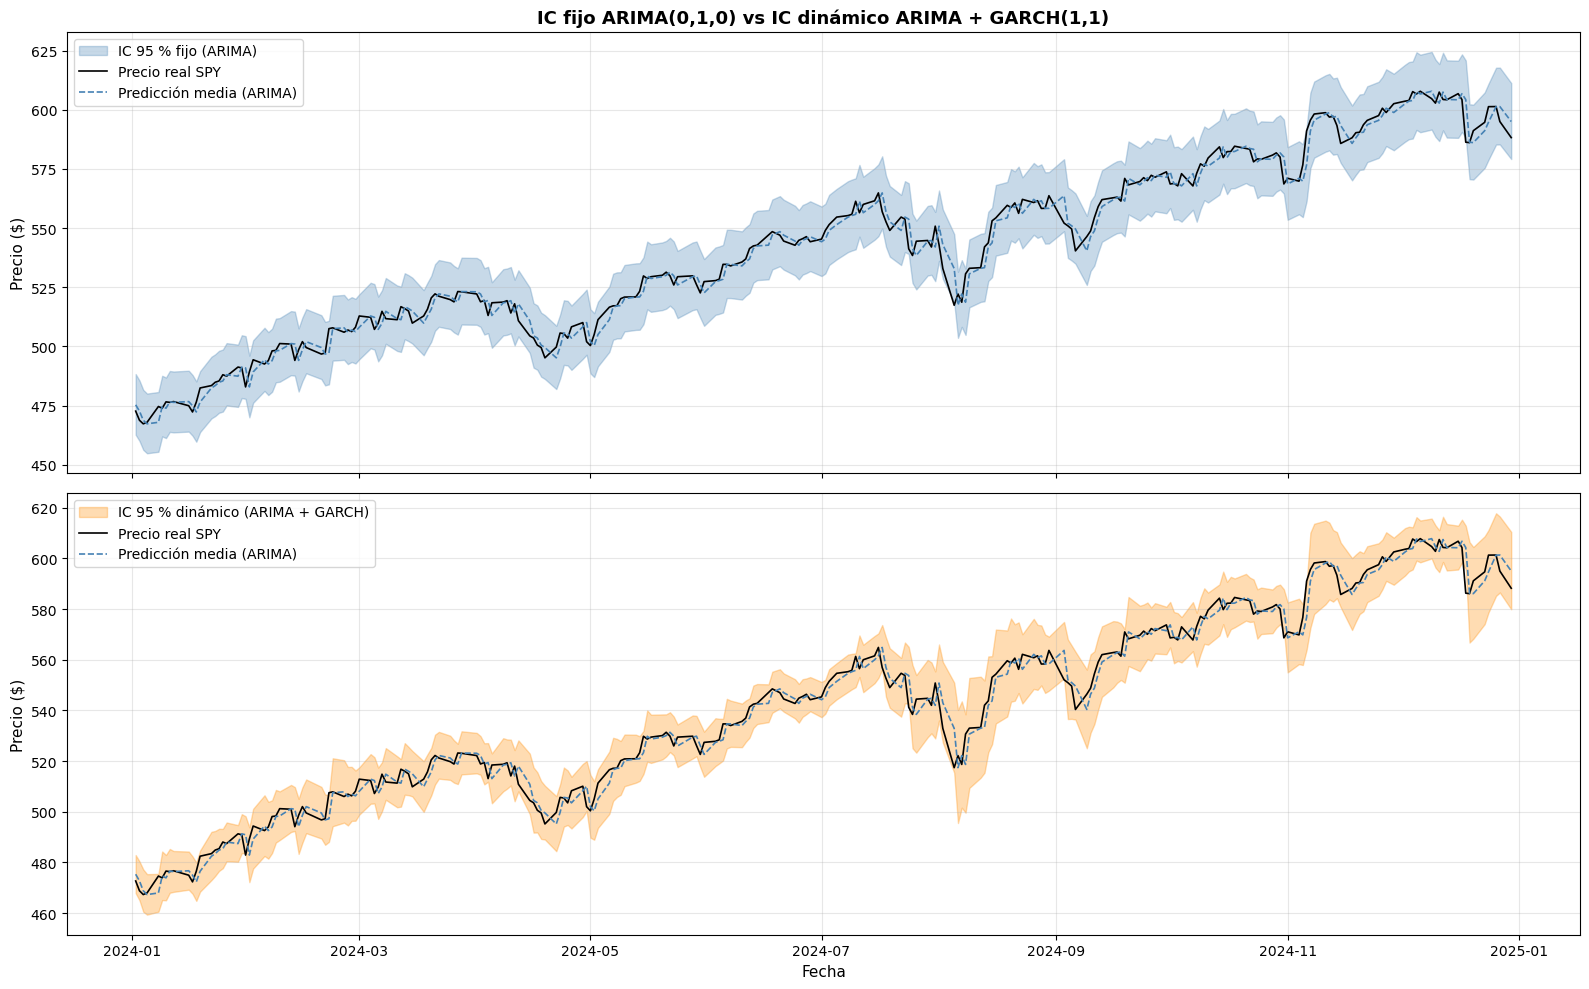

In [62]:
# Por último hacemos algunos g´raficos para representar nuestros resultados donde:
# Gráfico 1 — Banda de confianza ESTÁTICA
# Gráfico 2 — Banda de confianza DINÁMICA

sigma_incond = res_train.std()  # desviación incondicional en % 
sigma_incond_log = sigma_incond / 100  # convertida a escala logarítmica

# Límites fijos en escala de precios
li_fijo = np.exp(np.log(df_resultado["pred"]) - t_critico * sigma_incond_log)
ls_fijo = np.exp(np.log(df_resultado["pred"]) + t_critico * sigma_incond_log)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Panel superior — IC fijo (ARIMA puro)
axes[0].fill_between(df_resultado.index, li_fijo, ls_fijo,
                     alpha=0.3, color="steelblue",
                     label="IC 95 % fijo (ARIMA)")
axes[0].plot(df_resultado.index, df_resultado["real"],
             color="black", linewidth=1.2, label="Precio real SPY")
axes[0].plot(df_resultado.index, df_resultado["pred"],
             color="steelblue", linewidth=1.2, linestyle="--",
             label="Predicción media (ARIMA)")
axes[0].set_ylabel("Precio ($)", fontsize=11)
axes[0].set_title("IC fijo ARIMA(0,1,0) vs IC dinámico ARIMA + GARCH(1,1)",
                  fontsize=13, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel inferior — IC dinámico (ARIMA + GARCH)
axes[1].fill_between(df_resultado.index,
                     df_resultado["LI_95"], df_resultado["LS_95"],
                     alpha=0.3, color="darkorange",
                     label="IC 95 % dinámico (ARIMA + GARCH)")
axes[1].plot(df_resultado.index, df_resultado["real"],
             color="black", linewidth=1.2, label="Precio real SPY")
axes[1].plot(df_resultado.index, df_resultado["pred"],
             color="steelblue", linewidth=1.2, linestyle="--",
             label="Predicción media (ARIMA)")
axes[1].set_ylabel("Precio ($)", fontsize=11)
axes[1].set_xlabel("Fecha", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()